## 1. Business Understanding

Tavoitteena on ennustaa, onko verkkosivu phishing-sivu vai tavallinen verkkosivu. Jos malli toimii riittävän hyvin, sitä voisi myöhemmin hyödyntää esimerkiksi automaattisessa varoitusjärjestelmässä.

## 2. Data Understanding

Data sisältää 11055 rows, 30 features ja yhden target variable
`result`. Kaikki arvot ovat integers, eikä puuttuvia arvoja ole.
1 = legit ja -1 = phishing.

In [1]:
from ucimlrepo import fetch_ucirepo 
  
# fetch dataset 
phishing_websites = fetch_ucirepo(id=327) 
  
# data (as pandas dataframes) 
X = phishing_websites.data.features 
y = phishing_websites.data.targets 
  
# metadata 
print(phishing_websites.metadata) 
  
# variable information 
print(phishing_websites.variables) 


{'uci_id': 327, 'name': 'Phishing Websites', 'repository_url': 'https://archive.ics.uci.edu/dataset/327/phishing+websites', 'data_url': 'https://archive.ics.uci.edu/static/public/327/data.csv', 'abstract': 'This dataset collected mainly from: PhishTank archive, MillerSmiles archive, Googleâ€™s searching operators.', 'area': 'Computer Science', 'tasks': ['Classification'], 'characteristics': ['Tabular'], 'num_instances': 11055, 'num_features': 30, 'feature_types': ['Integer'], 'demographics': [], 'target_col': ['result'], 'index_col': None, 'has_missing_values': 'no', 'missing_values_symbol': None, 'year_of_dataset_creation': 2012, 'last_updated': 'Tue Mar 05 2024', 'dataset_doi': '10.24432/C51W2X', 'creators': ['Rami Mohammad', 'Lee McCluskey'], 'intro_paper': {'ID': 396, 'type': 'NATIVE', 'title': 'An assessment of features related to phishing websites using an automated technique', 'authors': 'R. Mohammad, F. Thabtah, L. Mccluskey', 'venue': 'International Conference for Internet Tec

In [19]:
df = phishing_websites.data.features
df['result'] = phishing_websites.data.targets['result']

df.head()

,having_ip_address,url_length,shortining_service,having_at_symbol,double_slash_redirecting,prefix_suffix,having_sub_domain,sslfinal_state,domain_registration_length,favicon,...,popupwindow,iframe,age_of_domain,dnsrecord,web_traffic,page_rank,google_index,links_pointing_to_page,statistical_report,result
0,-1,1,1,1,-1,-1,-1,-1,-1,1,...,1,1,-1,-1,-1,-1,1,1,-1,-1
1,1,1,1,1,1,-1,0,1,-1,1,...,1,1,-1,-1,0,-1,1,1,1,-1
2,1,0,1,1,1,-1,-1,-1,-1,1,...,1,1,1,-1,1,-1,1,0,-1,-1
3,1,0,1,1,1,-1,-1,-1,1,1,...,1,1,-1,-1,1,-1,1,-1,1,-1
4,1,0,-1,1,1,-1,1,1,-1,1,...,-1,1,-1,-1,0,-1,1,1,1,1


In [20]:
df.dtypes


having_ip_address             int64
url_length                    int64
shortining_service            int64
having_at_symbol              int64
double_slash_redirecting      int64
prefix_suffix                 int64
having_sub_domain             int64
sslfinal_state                int64
domain_registration_length    int64
favicon                       int64
port                          int64
https_token                   int64
request_url                   int64
url_of_anchor                 int64
links_in_tags                 int64
sfh                           int64
submitting_to_email           int64
abnormal_url                  int64
redirect                      int64
on_mouseover                  int64
rightclick                    int64
popupwindow                   int64
iframe                        int64
age_of_domain                 int64
dnsrecord                     int64
web_traffic                   int64
page_rank                     int64
google_index                

In [21]:
df.isna().sum()

having_ip_address             0
url_length                    0
shortining_service            0
having_at_symbol              0
double_slash_redirecting      0
prefix_suffix                 0
having_sub_domain             0
sslfinal_state                0
domain_registration_length    0
favicon                       0
port                          0
https_token                   0
request_url                   0
url_of_anchor                 0
links_in_tags                 0
sfh                           0
submitting_to_email           0
abnormal_url                  0
redirect                      0
on_mouseover                  0
rightclick                    0
popupwindow                   0
iframe                        0
age_of_domain                 0
dnsrecord                     0
web_traffic                   0
page_rank                     0
google_index                  0
links_pointing_to_page        0
statistical_report            0
result                        0
dtype: i

# 3. Data Preparation

Jaetaan data train ja test-joukkoihin (75/25) niin, että luokkien
suhde pysyy samana molemmissa.

In [24]:
X = df.drop(['result'], axis=1)
y = df['result']

import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=20
)

print(X_train.shape, X_test.shape, y_train.shape, y_test.shape)

(8291, 30) (2764, 30) (8291,) (2764,)


# 4. Modeling — Decision Tree

Aloitetaan päätöspuulla. Puu rajoitetaan kahteen
tasoon.

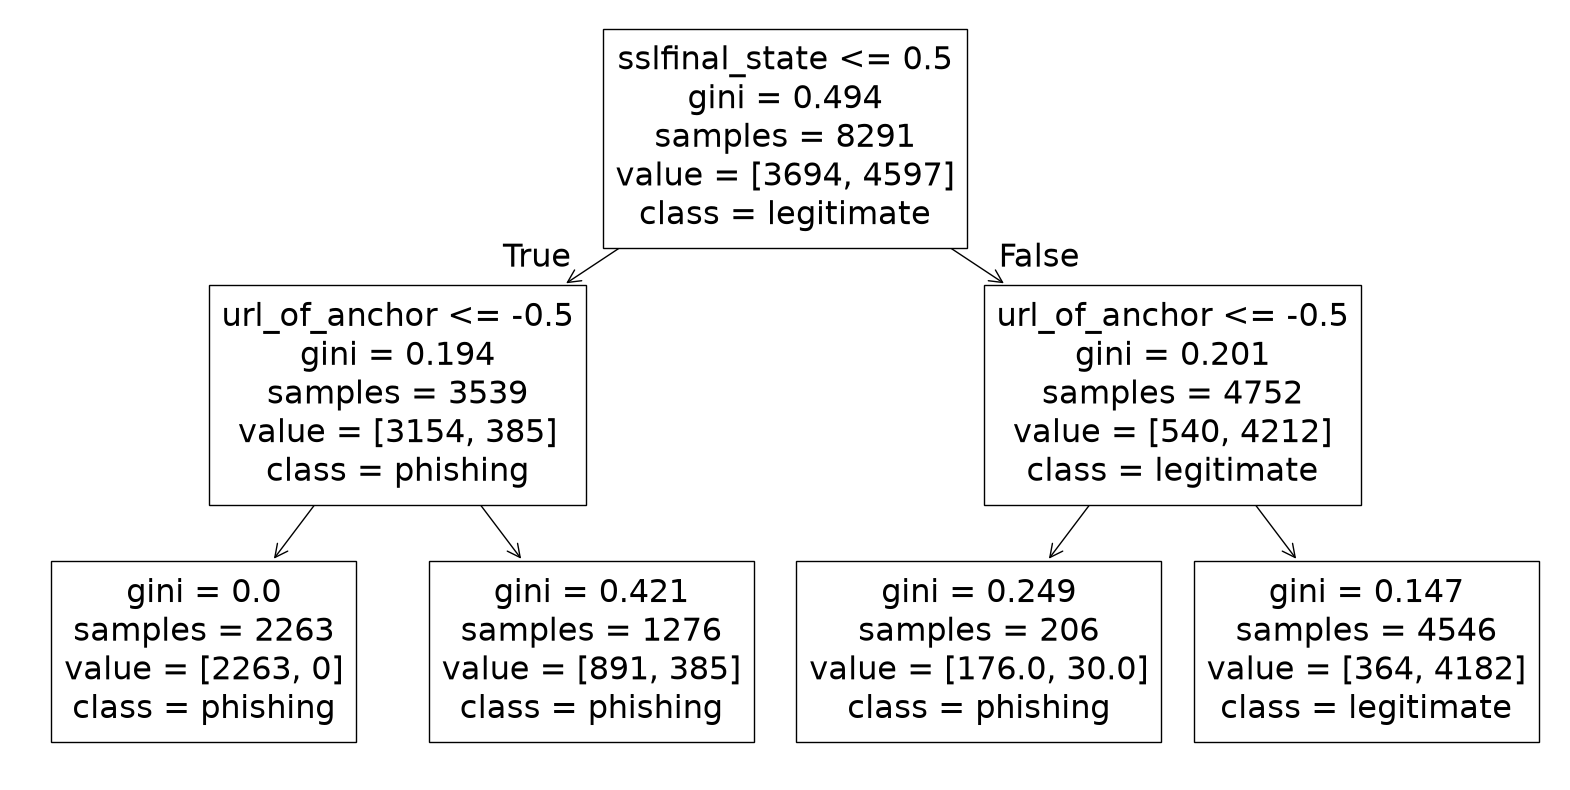

In [32]:
from sklearn.tree import DecisionTreeClassifier, plot_tree  
from sklearn.metrics import accuracy_score, classification_report

model = DecisionTreeClassifier(max_depth=2, random_state=20)
model.fit(X_train,y_train)

fig = plt.figure(figsize=(20, 10))
plot_tree(
    model,
    feature_names=X.columns,
    class_names=['phishing', 'legitimate'])
plt.show()

In [33]:
from sklearn.metrics import confusion_matrix

preds = model.predict(X_test)
confusion_matrix(y_test, preds)

array([[1095,  109],
       [ 148, 1412]])

In [34]:
print("Accuracy:", accuracy_score(y_test, preds))
print(classification_report(y_test, preds))

Accuracy: 0.9070188133140377
              precision    recall  f1-score   support

          -1       0.88      0.91      0.89      1204
           1       0.93      0.91      0.92      1560

    accuracy                           0.91      2764
   macro avg       0.90      0.91      0.91      2764
weighted avg       0.91      0.91      0.91      2764



## Ohjeet IT-asiantuntijalle

Aloita päätöspuun yläosasta ja tarkista solmussa näkyvä ominaisuus.

1. Tarkista `sslfinal_state`.
   - Jos arvo on pienempi tai yhtä suuri kuin 0.5, seuraa vasenta
     haaraa → phishing.
   - Jos arvo on suurempi kuin 0.5, seuraa oikeaa haaraa.

2. Jos päädyit oikeaan haaraan, tarkista `url_of_anchor`.
   - Jos arvo on pienempi tai yhtä suuri kuin -0.5 → phishing.
   - Jos arvo on suurempi kuin -0.5 → legit.

Jatka, kunnes saavut leaf nodeen. Leaf node kertoo lopullisen
tuloksen.

# 5. Modeling — Random Forest

Korvataan päätöspuu satunnaismetsällä. Se rakentaa monta puuta
ja äänestää lopputuloksen.

In [30]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score

rf = RandomForestClassifier(
    n_estimators=100,
    bootstrap=True,
    max_samples=0.7,
    max_features=0.75,
    random_state=20
)

cv_scores = cross_val_score(rf, X_train, y_train, cv=5)
print(f'Fold accuracies: {cv_scores}')
print(f'Mean accuracy: {cv_scores.mean():.4f}')

Fold accuracies: [0.95840868 0.97165259 0.96622437 0.95778046 0.96139928]
Mean accuracy: 0.9631


In [31]:
rf.fit(X_train, y_train)
preds_rf = rf.predict(X_test)

print("Accuracy:", accuracy_score(y_test, preds_rf))
print(confusion_matrix(y_test, preds_rf))
print(classification_report(y_test, preds_rf))

Accuracy: 0.9750361794500724
[[1164   40]
 [  29 1531]]
              precision    recall  f1-score   support

          -1       0.98      0.97      0.97      1204
           1       0.97      0.98      0.98      1560

    accuracy                           0.98      2764
   macro avg       0.98      0.97      0.97      2764
weighted avg       0.98      0.98      0.98      2764



# 6. Evaluation

Mallit arvioitiin testijoukolla, jota ei käytetty koulutuksessa.

**Päätöspuu (max_depth=2)**

Päätöspuun accuracy oli 0.91. Phishing-luokan (-1) precision oli 0.88, recall 0.91 ja F1 0.89, ja legit-luokan (1) precision 0.93, recall 0.91 ja F1 0.92. Confusion matrixista nähdään, että 148 phishing-sivua jäi tunnistamatta ja 109 legit-sivua leimattiin virheellisesti phishingiksi.

**Satunnaismetsä**

Satunnaismetsän cross-val accuracy oli 0.9631 ja testi-accuracy 0.975. Phishing-luokan precision oli 0.98, recall 0.97 ja F1 0.97, ja legit-luokan precision 0.97, recall 0.98 ja F1 0.98. Vain 29 phishing-sivua jäi tunnistamatta ja 40 legit-sivua leimattiin phishingiksi.

**Yhteenveto**

Satunnaismetsä parantaa kaikkia lukuja selvästi päätöspuuhun verrattuna, erityisesti phishing-luokan recallia (0.91 → 0.97). 

# 7. Deployment

Satunnaismetsää voidaan käyttää järjestelmässä, joka tarkistaa
verkkosivun featuret ja varoittaa käyttäjää ennen kuin hän avaa
phishing-sivun.

Malli ratkaisi alkuperäisen ongelman: se tunnistaa phishing-sivut
luotettavasti. Mallia pitäisi kuitenkin seurata ja kouluttaa
uudelleen, koska phishing-sivustot muuttuvat nopeasti.